In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px

import statsmodels.api as sm
import statsmodels.stats.api as sms
from statsmodels.graphics.gofplots import qqplot
from statsmodels.graphics.regressionplots import influence_plot
from scipy import stats
rng = np.random.default_rng(42)

from sklearn.linear_model import Ridge, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_percentage_error, mean_squared_error

# Data Preparation

In [2]:

# %% [markdown]
# ## Parameters & Calendar Features
# - Weeks: 104 (about 2 years)
# - Start: 2024-01-01 (weekly, Tuesday starts)

# %%
weeks = 104
start_date = pd.Timestamp('2024-01-01')
week_starts = pd.date_range(start=start_date, periods=weeks, freq='W-MON')

week_of_year = week_starts.isocalendar().week.astype(int)
monsoon_dummy = ((week_of_year >= 24) & (week_of_year <= 40)).astype(int)

# Fourier seasonality (annual)
season_sin = np.sin(2 * np.pi * week_of_year / 52)
season_cos = np.cos(2 * np.pi * week_of_year / 52)

# Slow trend
trend = np.linspace(0, 1, weeks)


In [3]:

# %% [markdown]
# ## Commercial & Contextual Drivers
# - Price index, competitor price index, availability, promo depth
# - Weather proxy (rainfall), fuel index

# %%
# Price / competitor price as clipped random walks
price_index = 1.0 + np.cumsum(rng.normal(0, 0.003, weeks))
price_index = np.clip(price_index, 0.92, 1.08)
comp_price_index = 1.0 + np.cumsum(rng.normal(0, 0.003, weeks))
comp_price_index = np.clip(comp_price_index, 0.92, 1.08)

# Availability improving over time
availability = 0.78 + 0.15 * trend + rng.normal(0, 0.01, weeks)
availability = np.clip(availability, 0.70, 0.95)

# Promotions with 3 waves
promo = np.clip(rng.beta(2, 10, weeks) * 0.25, 0, 0.25)
for center in [20, 45, 80]:
    lo, hi = max(0, center-3), min(weeks, center+4)
    promo[lo:hi] += rng.uniform(0.05, 0.12)
promo = np.clip(promo, 0, 0.30)

# Weather & fuel
rainfall = rng.gamma(shape=2.0, scale=5.0, size=weeks) + monsoon_dummy * rng.gamma(5.0, 15.0, weeks)
fuel_index = 1.0 + np.cumsum(rng.normal(0, 0.0015, weeks))


In [4]:

# %% [markdown]
# ## Paid Media & Owned Signals
# Weekly spends in lakhs; owned/1P signals in thousands.

# %%

def bursty_spend(base, spike_prob=0.12, spike_mult=(2.0, 4.0)):
    x = rng.gamma(2.0, base, weeks)
    spikes = rng.random(weeks) < spike_prob
    x[spikes] *= rng.uniform(spike_mult[0], spike_mult[1], spikes.sum())
    return x

# Media spends (lakhs)
tv_spend = bursty_spend(2.5, spike_prob=0.10, spike_mult=(3, 6))
yt_spend = bursty_spend(1.5, spike_prob=0.15, spike_mult=(2, 4))
fb_ig_spend = bursty_spend(1.2, spike_prob=0.18, spike_mult=(2, 3.5))
search_spend = bursty_spend(0.9, spike_prob=0.08, spike_mult=(1.5, 2.5)) + 0.7
display_spend = bursty_spend(0.7, spike_prob=0.12, spike_mult=(1.8, 3))
influencer_spend = bursty_spend(0.5, spike_prob=0.08, spike_mult=(2.5, 5))
ooh_spend = bursty_spend(1.0, spike_prob=0.08, spike_mult=(2.5, 4.5))
radio_spend = bursty_spend(0.6, spike_prob=0.10, spike_mult=(2.0, 3.5))

# Owned / 1P (thousands)
crm_email_sends = (rng.poisson(12, weeks) + monsoon_dummy * 10).astype(int)
website_sessions = (rng.normal(120, 15, weeks) + monsoon_dummy * 30 + promo * 200).clip(60).astype(int)


In [5]:

# %% [markdown]
# ## Response Curves: Adstock (carryover) + Hill (saturation)

# %%

def adstock(x, decay):
    y = np.zeros_like(x, dtype=float)
    for t in range(len(x)):
        y[t] = x[t] + (decay * y[t-1] if t > 0 else 0)
    return y

# Hill-type saturation

def hill(x, alpha=1.2, half_saturation=None):
    x = np.asarray(x, dtype=float)
    if half_saturation is None:
        half_saturation = np.percentile(x, 60)
    return np.power(x, alpha) / (np.power(x, alpha) + np.power(half_saturation, alpha))

transforms = {
    'tv':        dict(decay=0.60, alpha=1.6),
    'yt':        dict(decay=0.50, alpha=1.4),
    'fb':        dict(decay=0.45, alpha=1.35),
    'search':    dict(decay=0.30, alpha=1.25),
    'display':   dict(decay=0.35, alpha=1.25),
    'influencer':dict(decay=0.50, alpha=1.5),
    'ooh':       dict(decay=0.70, alpha=1.5),
    'radio':     dict(decay=0.55, alpha=1.35),
}

spend_dict = {
    'tv': tv_spend,
    'yt': yt_spend,
    'fb': fb_ig_spend,
    'search': search_spend,
    'display': display_spend,
    'influencer': influencer_spend,
    'ooh': ooh_spend,
    'radio': radio_spend,
}

adstocked = {}
saturated = {}
for ch, spend in spend_dict.items():
    a = adstock(spend, transforms[ch]['decay'])
    s = hill(a, alpha=transforms[ch]['alpha'])
    adstocked[ch] = a
    saturated[ch] = s


In [6]:

# %% [markdown]
# ## Synthetic Data Generating Process (Sales Units & Revenue)
# Baseline + media effects + noise; revenue = units × realized price.

# %%
# Baseline demand before media
base_units = (
    850
    + 60 * trend
    + 70 * monsoon_dummy
    + 55 * season_sin
    + 30 * season_cos
    + 400 * promo
    + 380 * (availability - 0.75)
    - 520 * (price_index - 1.0)
    - 220 * (comp_price_index - 1.0)
    + 0.08 * rainfall
)

# Media effect scales (units)
media_betas = {
    'tv': 520,
    'yt': 340,
    'fb': 260,
    'search': 300,
    'display': 140,
    'influencer': 180,
    'ooh': 200,
    'radio': 160,
}

media_units = np.zeros(weeks)
for ch, beta in media_betas.items():
    media_units += beta * saturated[ch]

# Random noise
noise = rng.normal(0, 25, weeks)

sales_units = np.clip(base_units + media_units + noise, 200, None)

# Price & revenue
price_per_unit = 9000 * price_index


In [7]:

# %% [markdown]
# ## Assemble Dataset & Export CSV

# %%

cols = {
    'week_start': week_starts,
    'week_of_year': week_of_year,
    'monsoon_dummy': monsoon_dummy,
    'trend': trend,
    'season_sin': season_sin,
    'season_cos': season_cos,
    'price_index': price_index,
    'comp_price_index': comp_price_index,
    'availability': availability,
    'promo_discount': promo,
    'rainfall_mm': rainfall,
    'fuel_price_index': fuel_index,
    'tv_spend_lakhs': tv_spend,
    'yt_spend_lakhs': yt_spend,
    'fb_ig_spend_lakhs': fb_ig_spend,
    'search_spend_lakhs': search_spend,
    'display_spend_lakhs': display_spend,
    'influencer_spend_lakhs': influencer_spend,
    'ooh_spend_lakhs': ooh_spend,
    'radio_spend_lakhs': radio_spend,
    'crm_email_sends_k': crm_email_sends,
    'website_sessions_k': website_sessions,
    'sales_units': sales_units.astype(int),
    'price_per_unit_inr': price_per_unit,
}

df = pd.DataFrame(cols)

csv_path = 'bridgestone_suv_mmm_weekly_data.csv'
df.to_csv(csv_path, index=False)
print(f"Saved dataset -> {csv_path} | shape={df.shape}")
df.head()


Saved dataset -> bridgestone_suv_mmm_weekly_data.csv | shape=(104, 24)


,week_start,week_of_year,monsoon_dummy,trend,season_sin,season_cos,price_index,comp_price_index,availability,promo_discount,...,fb_ig_spend_lakhs,search_spend_lakhs,display_spend_lakhs,influencer_spend_lakhs,ooh_spend_lakhs,radio_spend_lakhs,crm_email_sends_k,website_sessions_k,sales_units,price_per_unit_inr
2024-01-01,2024-01-01,1,0,0.000000,0.120537,0.992709,1.000914,0.997199,0.771218,0.072379,...,2.138139,1.472650,0.543860,0.199375,0.906058,0.831222,12,122,1220,9008.227361
2024-01-08,2024-01-08,2,0,0.009709,0.239316,0.970942,0.997794,0.996583,0.778115,0.029559,...,0.425337,1.453630,0.229071,0.423040,2.725741,0.822977,12,124,1239,8980.147790
2024-01-15,2024-01-15,3,0,0.019417,0.354605,0.935016,1.000046,0.993733,0.792072,0.056613,...,4.044039,2.489031,1.835140,1.207984,0.693832,1.577806,16,129,1723,9000.409973
2024-01-22,2024-01-22,4,0,0.029126,0.464723,0.885456,1.002867,0.992716,0.771105,0.047403,...,2.226659,2.978754,1.575280,1.207904,1.246635,1.130407,11,96,1775,9025.805220
2024-01-29,2024-01-29,5,0,0.038835,0.568065,0.822984,0.997014,0.995237,0.786132,0.040662,...,1.615013,2.545799,2.032815,0.875725,0.422382,0.866086,12,124,1668,8973.127270


# Analysis

In [8]:
df = pd.read_csv('bridgestone_suv_mmm_weekly_data.csv')
df.head()

,week_start,week_of_year,monsoon_dummy,trend,season_sin,season_cos,price_index,comp_price_index,availability,promo_discount,...,fb_ig_spend_lakhs,search_spend_lakhs,display_spend_lakhs,influencer_spend_lakhs,ooh_spend_lakhs,radio_spend_lakhs,crm_email_sends_k,website_sessions_k,sales_units,price_per_unit_inr
0,2024-01-01,1,0,0.000000,0.120537,0.992709,1.000914,0.997199,0.771218,0.072379,...,2.138139,1.472650,0.543860,0.199375,0.906058,0.831222,12,122,1220,9008.227361
1,2024-01-08,2,0,0.009709,0.239316,0.970942,0.997794,0.996583,0.778115,0.029559,...,0.425337,1.453630,0.229071,0.423040,2.725741,0.822977,12,124,1239,8980.147790
2,2024-01-15,3,0,0.019417,0.354605,0.935016,1.000046,0.993733,0.792072,0.056613,...,4.044039,2.489031,1.835140,1.207984,0.693832,1.577806,16,129,1723,9000.409973
3,2024-01-22,4,0,0.029126,0.464723,0.885456,1.002867,0.992716,0.771105,0.047403,...,2.226659,2.978754,1.575280,1.207904,1.246635,1.130407,11,96,1775,9025.805220
4,2024-01-29,5,0,0.038835,0.568065,0.822984,0.997014,0.995237,0.786132,0.040662,...,1.615013,2.545799,2.032815,0.875725,0.422382,0.866086,12,124,1668,8973.127270


In [9]:
df['sales_revenue_inr'] = df['sales_units'] * df['price_per_unit_inr']

In [10]:
df.head()

,week_start,week_of_year,monsoon_dummy,trend,season_sin,season_cos,price_index,comp_price_index,availability,promo_discount,...,search_spend_lakhs,display_spend_lakhs,influencer_spend_lakhs,ooh_spend_lakhs,radio_spend_lakhs,crm_email_sends_k,website_sessions_k,sales_units,price_per_unit_inr,sales_revenue_inr
0,2024-01-01,1,0,0.000000,0.120537,0.992709,1.000914,0.997199,0.771218,0.072379,...,1.472650,0.543860,0.199375,0.906058,0.831222,12,122,1220,9008.227361,1.099004e+07
1,2024-01-08,2,0,0.009709,0.239316,0.970942,0.997794,0.996583,0.778115,0.029559,...,1.453630,0.229071,0.423040,2.725741,0.822977,12,124,1239,8980.147790,1.112640e+07
2,2024-01-15,3,0,0.019417,0.354605,0.935016,1.000046,0.993733,0.792072,0.056613,...,2.489031,1.835140,1.207984,0.693832,1.577806,16,129,1723,9000.409973,1.550771e+07
3,2024-01-22,4,0,0.029126,0.464723,0.885456,1.002867,0.992716,0.771105,0.047403,...,2.978754,1.575280,1.207904,1.246635,1.130407,11,96,1775,9025.805220,1.602080e+07
4,2024-01-29,5,0,0.038835,0.568065,0.822984,0.997014,0.995237,0.786132,0.040662,...,2.545799,2.032815,0.875725,0.422382,0.866086,12,124,1668,8973.127270,1.496718e+07


# Initial OLS Model

In [11]:
target_col = "sales_units"  # change to "sales_revenue_inr" if you want to diagnose revenue

raw_feature_cols = [
    # PAID MEDIA (raw spends, lakhs)
    "tv_spend_lakhs","yt_spend_lakhs","fb_ig_spend_lakhs","search_spend_lakhs",
    "display_spend_lakhs","influencer_spend_lakhs","ooh_spend_lakhs","radio_spend_lakhs",
    # OWNED / 1P
    "website_sessions_k","crm_email_sends_k",
    # COMMERCIALS
    "price_index","comp_price_index","promo_discount","availability",
    # SEASONALITY / CONTEXT
    "season_sin","season_cos","monsoon_dummy","trend","rainfall_mm","fuel_price_index",
]


used_cols = raw_feature_cols + [target_col]
d = df[used_cols].dropna().copy()

X_raw = d[raw_feature_cols].astype(float)
y = d[target_col].astype(float).values

# Fit a baseline OLS (with intercept) once; later cells will use it
Xc = sm.add_constant(X_raw, has_constant="add")
ols_raw = sm.OLS(y, Xc).fit()

print(f"X_raw shape: {X_raw.shape}, y length: {len(y)}")
print(ols_raw.summary())

X_raw shape: (104, 20), y length: 104
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.708
Model:                            OLS   Adj. R-squared:                  0.637
Method:                 Least Squares   F-statistic:                     10.05
Date:                Mon, 16 Mar 2026   Prob (F-statistic):           9.06e-15
Time:                        17:49:27   Log-Likelihood:                -618.93
No. Observations:                 104   AIC:                             1280.
Df Residuals:                      83   BIC:                             1335.
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------

# Checking OLS Assumptions

In [12]:
# CLinearity/specification
# Rainbow test: linearity of the conditional mean

rainbow_stat, rainbow_p = sms.linear_rainbow(ols_raw)
print(f"Rainbow test: F={rainbow_stat:.3f}, p={rainbow_p:.4f}  (p>0.05 → linearity not rejected)")

Rainbow test: F=1.650, p=0.0688  (p>0.05 → linearity not rejected)


In [13]:
# Independence
# Durbin–Watson (~2 indicates no strong AR(1))
dw = sm.stats.stattools.durbin_watson(ols_raw.resid)
print(f"Durbin–Watson: {dw:.3f}  (≈2 is ideal)")

# Ljung–Box test at multiple lags
lbq = sm.stats.acorr_ljungbox(ols_raw.resid, lags=[4, 8, 12], return_df=True)
lbq.columns = ["LB stat", "p-value"]
print("\nLjung–Box (lags 4/8/12):")
display(lbq)

Durbin–Watson: 0.835  (≈2 is ideal)

Ljung–Box (lags 4/8/12):


,LB stat,p-value
4,32.028138,0.000002
8,40.316533,0.000003
12,44.581538,0.000012


In [14]:
# Homoscedasticity
bp_stat = sms.het_breuschpagan(ols_raw.resid, Xc)
bp = dict(zip(['LM stat','LM p','F stat','F p'], bp_stat))

white_stat = sms.het_white(ols_raw.resid, Xc)
white = dict(zip(['LM stat','LM p','F stat','F p'], white_stat))

print(f"Breusch–Pagan p-value: {bp['LM p']:.4f} (p>0.05 → homoskedastic)")
print(f"White test p-value:    {white['LM p']:.4f} (p>0.05 → homoskedastic)")

Breusch–Pagan p-value: 0.0724 (p>0.05 → homoskedastic)
White test p-value:    0.4539 (p>0.05 → homoskedastic)


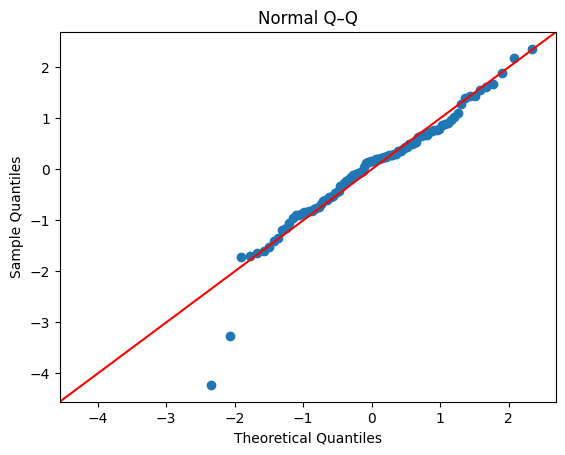

Shapiro–Wilk: W=0.952, p=0.0009 (p>0.05 ≈ normal)
Anderson–Darling: stat=0.893 | critical=[0.556 0.633 0.76  0.886 1.054] @ [15.  10.   5.   2.5  1. ]%


In [15]:
# Normality of residuals
resid = ols_raw.resid

# Q–Q plot
qqplot(resid, line='45', fit=True)
plt.title("Normal Q–Q")
plt.show()

# Shapiro–Wilk (small-n sensitive)
W, shapiro_p = stats.shapiro(resid)
print(f"Shapiro–Wilk: W={W:.3f}, p={shapiro_p:.4f} (p>0.05 ≈ normal)")

# Anderson–Darling (reports critical values)
ad = stats.anderson(resid, dist='norm')
print(f"Anderson–Darling: stat={ad.statistic:.3f} | critical={ad.critical_values} @ {ad.significance_level}%")

In [16]:
# Multicollinearity

def vif_dataframe(X: pd.DataFrame):
    """Compute Variance Inflation Factors (VIF) for features in X."""
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    Xc = sm.add_constant(X, has_constant="add")
    rows = []
    for i, col in enumerate(Xc.columns):
        if col == "const":
            continue
        rows.append({"feature": col, "VIF": variance_inflation_factor(Xc.values, i)})
    return pd.DataFrame(rows).sort_values("VIF", ascending=False)

cond_no = np.linalg.cond(Xc.values)
print(f"Condition number: {cond_no:.1f}  (>30 may indicate issues)")

vif_df = vif_dataframe(X_raw)
display(vif_df)

Condition number: 108916.6  (>30 may indicate issues)


,feature,VIF
17,trend,30.182853
13,availability,25.832806
16,monsoon_dummy,14.913358
19,fuel_price_index,8.210920
18,rainfall_mm,7.043319
9,crm_email_sends_k,4.996222
14,season_sin,4.674470
15,season_cos,3.105683
8,website_sessions_k,3.001928
11,comp_price_index,2.392317


# Some quick Linearity visualizations

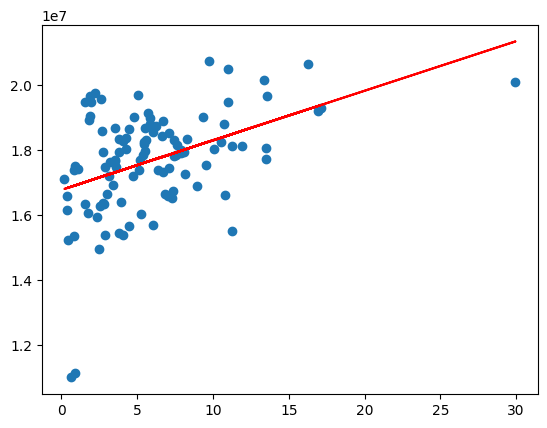

In [17]:
plt.scatter(df['tv_spend_lakhs'], df['sales_revenue_inr'])
z1 = np.polyfit(df['tv_spend_lakhs'], df['sales_revenue_inr'], 1)
p1 = np.poly1d(z1)
plt.plot(df['tv_spend_lakhs'], p1(df['tv_spend_lakhs']), "r-", label="Linear Trend Line")
plt.show()

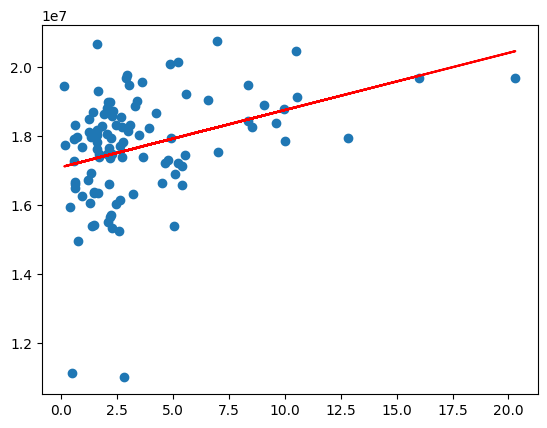

In [18]:
plt.scatter(df['yt_spend_lakhs'], df['sales_revenue_inr'])
z1 = np.polyfit(df['yt_spend_lakhs'], df['sales_revenue_inr'], 1)
p1 = np.poly1d(z1)
plt.plot(df['yt_spend_lakhs'], p1(df['yt_spend_lakhs']), "r-", label="Linear Trend Line")
plt.show()

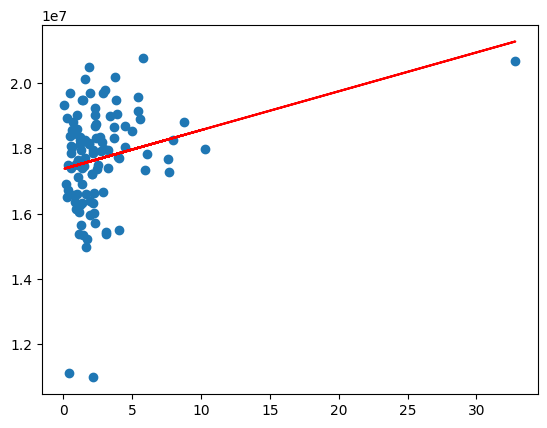

In [19]:
plt.scatter(df['fb_ig_spend_lakhs'], df['sales_revenue_inr'])
z1 = np.polyfit(df['fb_ig_spend_lakhs'], df['sales_revenue_inr'], 1)
p1 = np.poly1d(z1)
plt.plot(df['fb_ig_spend_lakhs'], p1(df['fb_ig_spend_lakhs']), "r-", label="Linear Trend Line")
plt.show()

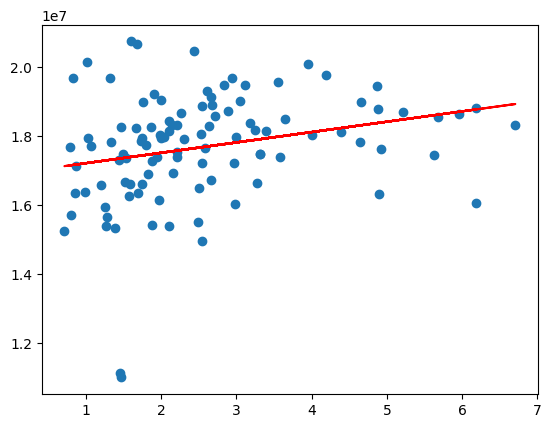

In [20]:
plt.scatter(df['search_spend_lakhs'], df['sales_revenue_inr'])
z1 = np.polyfit(df['search_spend_lakhs'], df['sales_revenue_inr'], 1)
p1 = np.poly1d(z1)
plt.plot(df['search_spend_lakhs'], p1(df['search_spend_lakhs']), "r-", label="Linear Trend Line")
plt.show()

# Ridge regression after OLS assumptions checks

In [21]:
X = df[['monsoon_dummy', 'trend', 'season_sin',
       'season_cos', 'price_index', 'comp_price_index', 'availability',
       'promo_discount', 'rainfall_mm', 'fuel_price_index', 'tv_spend_lakhs',
       'yt_spend_lakhs', 'fb_ig_spend_lakhs', 'search_spend_lakhs',
       'display_spend_lakhs', 'influencer_spend_lakhs', 'ooh_spend_lakhs',
       'radio_spend_lakhs', 'crm_email_sends_k', 'website_sessions_k']]

y = df['sales_units']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

ridge = Ridge(alpha=5.0, fit_intercept=True, random_state=42)
ridge.fit(X_train, y_train)

y_pred_train = ridge.predict(X_train)
y_pred_test = ridge.predict(X_test)

r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
mape_test = mean_absolute_percentage_error(y_test, y_pred_test)
mse_test = mean_squared_error(y_test, y_pred_test)

print({
    'R2_train': round(float(r2_train), 3),
    'R2_test': round(float(r2_test), 3),
    'MAPE_test': round(float(mape_test), 3),
    'MSE_test' : round(float(mse_test), 3)
})

{'R2_train': 0.628, 'R2_test': 0.44, 'MAPE_test': 0.032, 'MSE_test': 6123.565}


# Adstock and Hill transformation as per the OLS Assumption check results

In [22]:
# ## Response Curves: Adstock (carryover) + Hill (saturation)

# %%

def adstock(x, decay):
    y = np.zeros_like(x, dtype=float)
    for t in range(len(x)):
        y[t] = x[t] + (decay * y[t-1] if t > 0 else 0)
    return y

# Hill-type saturation

def hill(x, alpha=1.2, half_saturation=None):
    x = np.asarray(x, dtype=float)
    if half_saturation is None:
        half_saturation = np.percentile(x, 60)
    return np.power(x, alpha) / (np.power(x, alpha) + np.power(half_saturation, alpha))

transforms = {
    'tv':        dict(decay=0.60, alpha=1.6),
    'yt':        dict(decay=0.50, alpha=1.4),
    'fb':        dict(decay=0.45, alpha=1.35),
    'search':    dict(decay=0.30, alpha=1.25),
    'display':   dict(decay=0.35, alpha=1.25),
    'influencer':dict(decay=0.50, alpha=1.5),
    'ooh':       dict(decay=0.70, alpha=1.5),
    'radio':     dict(decay=0.55, alpha=1.35),
}

spend_dict = {
    'tv': df['tv_spend_lakhs'],
    'yt': df['yt_spend_lakhs'],
    'fb': df['fb_ig_spend_lakhs'],
    'search': df['search_spend_lakhs'],
    'display': df['display_spend_lakhs'],
    'influencer': df['influencer_spend_lakhs'],
    'ooh': df['ooh_spend_lakhs'],
    'radio': df['radio_spend_lakhs'],
}

adstocked = {}
saturated = {}
for ch, spend in spend_dict.items():
    a = adstock(spend, transforms[ch]['decay'])
    s = hill(a, alpha=transforms[ch]['alpha'])
    adstocked[ch] = a
    saturated[ch] = s

In [23]:
X = pd.DataFrame({
    'tv_m': saturated['tv'],
    'yt_m': saturated['yt'],
    'fb_m': saturated['fb'],
    'search_m': saturated['search'],
    'display_m': saturated['display'],
    'influencer_m': saturated['influencer'],
    'ooh_m': saturated['ooh'],
    'radio_m': saturated['radio'],
    'price_index': df['price_index'],
    'comp_price_index': df['comp_price_index'],
    'availability': df['availability'],
    'promo_discount': df['promo_discount'],
    'season_sin': df['season_sin'],
    'season_cos': df['season_cos'],
    'monsoon_dummy': df['monsoon_dummy'],
    'trend': df['trend'],
    'rainfall_mm': df['rainfall_mm'],
    'fuel_price_index': df['fuel_price_index'],
    'website_sessions_k': df['website_sessions_k'],
    'crm_email_sends_k': df['crm_email_sends_k'],
})

y = df['sales_units']

# OLS regression after transformation

In [24]:
target_col = "sales_units"  # change to "sales_revenue_inr" if you want to diagnose revenue

raw_feature_cols = list(X.columns)


used_cols = raw_feature_cols + [target_col]
d = X.join(y)[used_cols].dropna().copy()

X_raw = d[raw_feature_cols].astype(float)
y = d[target_col].astype(float).values

# Fit a baseline OLS (with intercept) once; later cells will use it
Xc = sm.add_constant(X_raw, has_constant="add")
ols_raw = sm.OLS(y, Xc).fit()

print(f"X_raw shape: {X_raw.shape}, y length: {len(y)}")
print(ols_raw.summary())

X_raw shape: (104, 20), y length: 104
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.980
Model:                            OLS   Adj. R-squared:                  0.975
Method:                 Least Squares   F-statistic:                     205.6
Date:                Mon, 16 Mar 2026   Prob (F-statistic):           4.64e-62
Time:                        17:49:28   Log-Likelihood:                -478.92
No. Observations:                 104   AIC:                             999.8
Df Residuals:                      83   BIC:                             1055.
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------

# OLS Assumptions check after tranformation

In [25]:
# CLinearity/specification
# Rainbow test: linearity of the conditional mean

rainbow_stat, rainbow_p = sms.linear_rainbow(ols_raw)
print(f"Rainbow test: F={rainbow_stat:.3f}, p={rainbow_p:.4f}  (p>0.05 → linearity not rejected)")

Rainbow test: F=0.909, p=0.6267  (p>0.05 → linearity not rejected)


In [26]:
# Independence
# Durbin–Watson (~2 indicates no strong AR(1))
dw = sm.stats.stattools.durbin_watson(ols_raw.resid)
print(f"Durbin–Watson: {dw:.3f}  (≈2 is ideal)")

# Ljung–Box test at multiple lags
lbq = sm.stats.acorr_ljungbox(ols_raw.resid, lags=[4, 8, 12], return_df=True)
lbq.columns = ["LB stat", "p-value"]
print("\nLjung–Box (lags 4/8/12):")
display(lbq)

Durbin–Watson: 2.212  (≈2 is ideal)

Ljung–Box (lags 4/8/12):


,LB stat,p-value
4,5.612647,0.230004
8,9.693921,0.287169
12,11.367040,0.497752


In [27]:
# Homoscedasticity
bp_stat = sms.het_breuschpagan(ols_raw.resid, Xc)
bp = dict(zip(['LM stat','LM p','F stat','F p'], bp_stat))

white_stat = sms.het_white(ols_raw.resid, Xc)
white = dict(zip(['LM stat','LM p','F stat','F p'], white_stat))

print(f"Breusch–Pagan p-value: {bp['LM p']:.4f} (p>0.05 → homoskedastic)")
print(f"White test p-value:    {white['LM p']:.4f} (p>0.05 → homoskedastic)")

Breusch–Pagan p-value: 0.1795 (p>0.05 → homoskedastic)
White test p-value:    0.4539 (p>0.05 → homoskedastic)


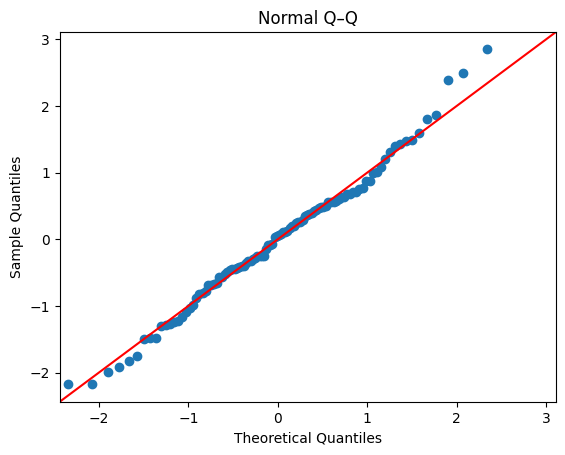

Shapiro–Wilk: W=0.990, p=0.5966 (p>0.05 ≈ normal)
Anderson–Darling: stat=0.276 | critical=[0.556 0.633 0.76  0.886 1.054] @ [15.  10.   5.   2.5  1. ]%


In [28]:
# Normality of residuals
resid = ols_raw.resid

# Q–Q plot
qqplot(resid, line='45', fit=True)
plt.title("Normal Q–Q")
plt.show()

# Shapiro–Wilk (small-n sensitive)
W, shapiro_p = stats.shapiro(resid)
print(f"Shapiro–Wilk: W={W:.3f}, p={shapiro_p:.4f} (p>0.05 ≈ normal)")

# Anderson–Darling (reports critical values)
ad = stats.anderson(resid, dist='norm')
print(f"Anderson–Darling: stat={ad.statistic:.3f} | critical={ad.critical_values} @ {ad.significance_level}%")

In [29]:
# Multicollinearity

def vif_dataframe(X: pd.DataFrame):
    """Compute Variance Inflation Factors (VIF) for features in X."""
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    Xc = sm.add_constant(X, has_constant="add")
    rows = []
    for i, col in enumerate(Xc.columns):
        if col == "const":
            continue
        rows.append({"feature": col, "VIF": variance_inflation_factor(Xc.values, i)})
    return pd.DataFrame(rows).sort_values("VIF", ascending=False)

cond_no = np.linalg.cond(Xc.values)
print(f"Condition number: {cond_no:.1f}  (>30 may indicate issues)")

vif_df = vif_dataframe(X_raw)
display(vif_df)

Condition number: 116777.4  (>30 may indicate issues)


,feature,VIF
15,trend,30.330244
10,availability,24.133100
14,monsoon_dummy,15.735531
17,fuel_price_index,9.979863
16,rainfall_mm,7.197534
12,season_sin,5.723198
13,season_cos,4.703123
19,crm_email_sends_k,4.673837
8,price_index,3.097328
18,website_sessions_k,2.948326


# Ridge regression

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

ridge = Ridge(alpha=5.0, fit_intercept=True, random_state=42)
ridge.fit(X_train, y_train)

y_pred_train = ridge.predict(X_train)
y_pred_test = ridge.predict(X_test)

r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
mape_test = mean_absolute_percentage_error(y_test, y_pred_test)
mse_test = mean_squared_error(y_test, y_pred_test)

print({
    'R2_train': round(float(r2_train), 3),
    'R2_test': round(float(r2_test), 3),
    'MAPE_test': round(float(mape_test), 3),
    'MSE_test' : round(float(mse_test), 3)
})

{'R2_train': 0.72, 'R2_test': 0.539, 'MAPE_test': 0.031, 'MSE_test': 5032.305}


# Linear regression for channel wise ROAS computation

In [31]:
ols = LinearRegression()
ols.fit(X, y)
coef = pd.Series(ols.coef_, index=X.columns)
contrib_df = X.multiply(coef, axis=1)

media_feats = ['tv_m','yt_m','fb_m','search_m','display_m','influencer_m','ooh_m','radio_m']

# Weekly channel units (no negatives for attribution reporting)
weekly_channel_units = contrib_df[media_feats].clip(lower=0)

# Revenue attribution uses realized price each week
price_series = pd.Series(df['price_per_unit_inr'].values, index=df.index)
weekly_channel_revenue = weekly_channel_units.mul(price_series, axis=0)
channel_revenue = weekly_channel_revenue.sum()
channel_units = weekly_channel_units.sum()

# Total channel spend in INR (lakhs -> INR)
spend_map = {
    'tv_m': 'tv_spend_lakhs',
    'yt_m': 'yt_spend_lakhs',
    'fb_m': 'fb_ig_spend_lakhs',
    'search_m': 'search_spend_lakhs',
    'display_m': 'display_spend_lakhs',
    'influencer_m': 'influencer_spend_lakhs',
    'ooh_m': 'ooh_spend_lakhs',
    'radio_m': 'radio_spend_lakhs',
}

channel_spend_inr = {feat: df[spend_map[feat]].sum() * 1e5 for feat in media_feats}
roas = {feat: float(channel_revenue[feat] / channel_spend_inr[feat]) for feat in media_feats}

summary = []
for feat in media_feats:
    ch = feat.replace('_m','').upper()
    summary.append({
        'Channel': ch,
        'Total Spend (INR)': round(channel_spend_inr[feat], 2),
        'Attributed Units': round(channel_units[feat], 1),
        'Attributed Revenue (INR)': round(channel_revenue[feat], 2),
        'ROAS (Revenue/Spend)': round(roas[feat], 2),
    })
summary_df = pd.DataFrame(summary).sort_values('Attributed Revenue (INR)', ascending=False)
summary_df

,Channel,Total Spend (INR),Attributed Units,Attributed Revenue (INR),ROAS (Revenue/Spend)
0,TV,62409048.25,25329.5,2.286271e+08,3.66
1,YT,37012010.77,17480.5,1.576779e+08,4.26
3,SEARCH,26740709.28,14790.6,1.334642e+08,4.99
2,FB,28312761.84,12927.4,1.166440e+08,4.12
6,OOH,22009421.82,11488.4,1.036621e+08,4.71
5,INFLUENCER,13855632.40,8803.8,7.951009e+07,5.74
4,DISPLAY,17025742.40,6962.8,6.280970e+07,3.69
7,RADIO,16462472.48,6823.6,6.161853e+07,3.74


# Validation visualiations

In [32]:
roas_plot = summary_df.sort_values('ROAS (Revenue/Spend)', ascending=False).copy()

fig_roas = px.bar(
    roas_plot,
    x='Channel',
    y='ROAS (Revenue/Spend)',
    text='ROAS (Revenue/Spend)',
    color_discrete_sequence=['#4e79a7'],
    title='ROAS by Channel'
)

fig_roas.update_traces(
    texttemplate='%{text:.2f}',
    textposition='outside',
    hovertemplate='Channel: %{x}<br>ROAS: %{y:.2f}<extra></extra>'
)
fig_roas.update_layout(
    xaxis_title='Channel',
    yaxis_title='ROAS (Revenue / Spend)',
    template='plotly_white',
    uniformtext_minsize=10,
    uniformtext_mode='hide',
    margin=dict(l=60, r=20, t=60, b=40)
)

fig_roas.update_yaxes(dtick=0.5)

fig_roas.show()

In [33]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x = np.arange(len(y_test)), y = y_test, mode='lines', name='Actual',
    line=dict(color='royalblue', width=3)
))
fig.add_trace(go.Scatter(
    x = np.arange(len(y_test)), y = ridge.predict(X_test), mode='lines', name='Ridge_Predicted',
    line=dict(color='seagreen', width=2)
))
fig.add_trace(go.Scatter(
    x = np.arange(len(y_test)), y = ols.predict(X_test), mode='lines', name='OLS_Predicted',
    line=dict(color='firebrick', width=2, dash='dash')
))


fig.update_layout(
    title="Holdout: Actual vs Predicted (Units)",
    xaxis_title="Weeks in Holdout",
    yaxis_title="Units",
    template="plotly_white",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="left", x=0),
    margin=dict(l=60, r=20, t=60, b=40),
)

fig.update_yaxes(range=[1200, 2700], dtick=200)

fig.show()
